(567, 92)
Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 's

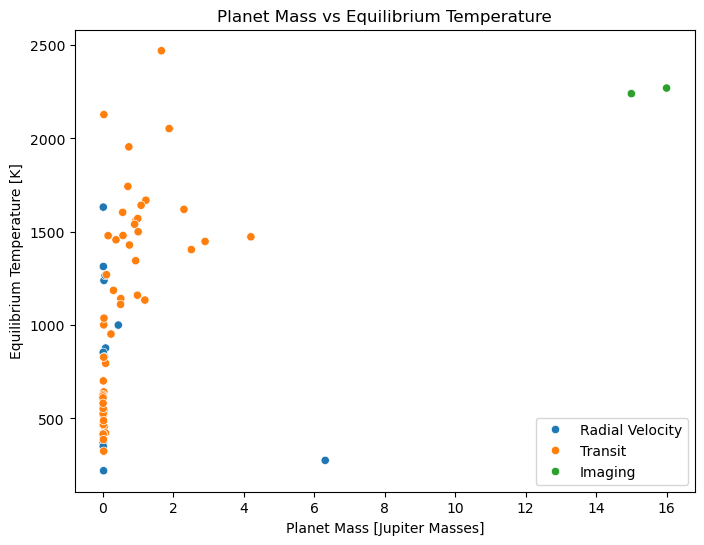

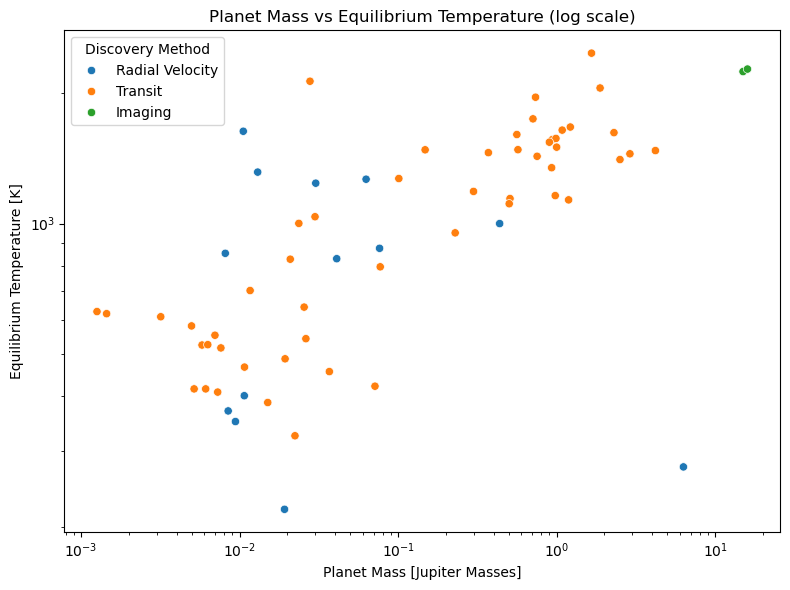

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 566, dtype: object


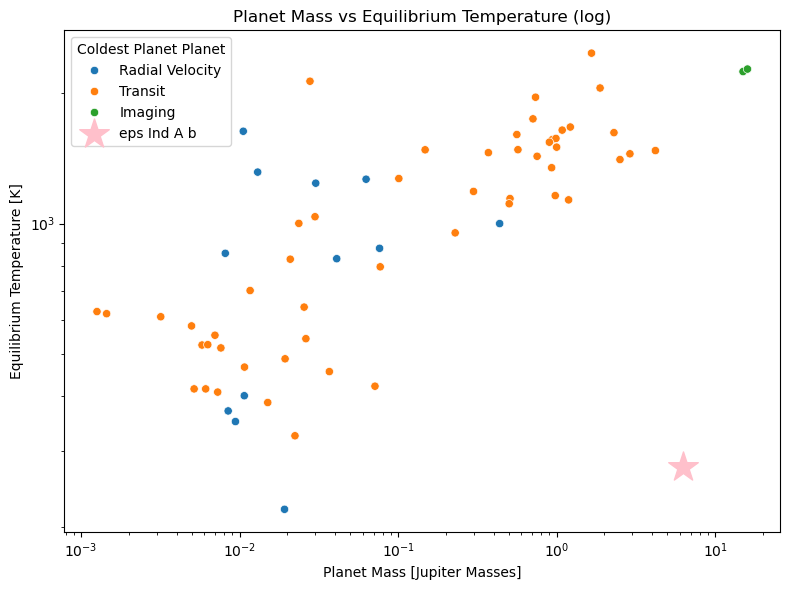

In [42]:
# File: analyze_exoplanet_data.ipynb

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 4.2: 567 rows, 92 columns


exo = pd.read_csv('exoplanet_data.csv.csv', comment = '#')
print(exo.shape) 
print(exo.columns)

# I do not know: 'pl_orbpererr1', ttv_flag', 'pl_insolerr2', 'pl_radeerr1', 'sy_kmagerr1'

# 4.3: Reducing Data
# pl_name = Planet Name, Planet name most commonly used in the literature - What the planet is called
# hostname = Host Name, Stellar name most commonly used in the literature - The star it revolves around
# discoverymethod = Discovery Method, Method by which the planet was first identified - Self Explanatory 
# st_spectype = Spectral Type, Classification of the star based on their spectral characteristics following the Morgan-Keenan system - OBAFGKM Classification
# pl_eqt = Equilibrium Temperature [K], The equilibrium temperature of the planet as modeled by a black body heated only by its host star, or for directly imaged planets, the effective temperature of the planet required to match the measured luminosity if the planet were a black body - Planet Thermal Equilibirum
# pl_bmassprov = Planet Mass or Mass*sin(i) [Jupiter Mass], Best planet mass estimate available, in order of preference: Mass, M*sin(i)/sin(i), or M*sin(i), depending on availability, and measured in Jupiter masses - Planet estimated mass

exo_small = exo[['pl_name','hostname','discoverymethod','st_spectype','pl_eqt','pl_bmassj']].dropna()

print(exo_small.shape) # (67, 6), 67 rows, 6 columns
print(exo_small.head())
print(exo_small.tail())
print(exo_small.columns)

# 4.4: Analyze Data

print(exo_small.value_counts('discoverymethod'))

# 4.4.1: There are 3 Discovery Methods: Transit(52) - Most, Radial Velocity(13), and Imaging(2) - Least.
# Transit - Exoplanet passes in front of its star as seen from earth, causing the brightness of the star to dim
# Radial Velocity - Observing a wobble from a star because of an exoplanet's gravitational pull
# Imaging - Capturing light reflected by an exoplanet directly.

plt.figure(figsize=(8,6))
sns.scatterplot(data=exo_small, x='pl_bmassj', y='pl_eqt', hue='discoverymethod')
plt.title('Planet Mass vs Equilibrium Temperature')
plt.xlabel('Planet Mass [Jupiter Masses]')
plt.ylabel('Equilibrium Temperature [K]')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=exo_small, x='pl_bmassj', y='pl_eqt', palette = 'tab10', hue = 'discoverymethod')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Planet Mass [Jupiter Masses]')
plt.ylabel('Equilibrium Temperature [K]')
plt.title('Planet Mass vs Equilibrium Temperature (log scale)')
plt.legend(title='Discovery Method')
plt.tight_layout()
plt.show()

# 4.4.3 - Exoplanets found by the imaging method are likely to be massive

massive = exo_small[exo_small['pl_bmassj'] > 5]
coldest = massive.loc[massive['pl_eqt'].idxmin()]
print(coldest)

# 4.4.6: eps Ind A b, Index: 566, 275 K, 6.31 Jupiter Masses, It is orbiting a K5 V star, one classification lower than the sun. So not exactly like the sun, but close enough.
:
# 4.4.7

plt.figure(figsize=(8, 6))
sns.scatterplot(data=exo_small, x='pl_bmassj', y='pl_eqt',hue = 'discoverymethod')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Planet Mass [Jupiter Masses]')
plt.ylabel('Equilibrium Temperature [K]')
plt.title('Planet Mass vs Equilibrium Temperature (log scale)')
plt.legend(title='Discovery Method')
plt.tight_layout()

plt.scatter(coldest['pl_bmassj'], coldest['pl_eqt'], marker ='*', s = 500, color='pink', label=coldest['pl_name'])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Planet Mass [Jupiter Masses]')
plt.ylabel('Equilibrium Temperature [K]')
plt.title('Planet Mass vs Equilibrium Temperature (log)')
plt.legend(title='Coldest Planet Planet')
plt.tight_layout()
plt.show()

# 4.5: Check your Answer
# a) A temperate super-Jupiter imaged with JWST in the mid-infrared
# b) Astronomers using the JWST were able to find 25 exoplanets through imaging, one of them being Eps Ind A. The new study found that previous data from this planet was incorrect.
# c) Its the same one that I found
# d) Yes

